
# Chen-Shu 2014 collocation-value Gegenbauer reconstruction

This notebook follows Chen and Shu (2014), Section 5, Examples 5.1 and 5.2.

Examples:

- Example 5.1: `f(x) = cos(x) + sin(x) sqrt(1+x)`.
- Example 5.2: `f(x) = cos(x) + sin(x) (1+x)^(1/3)`.

The notebook tests both:

- Fourier collocation on `2N+1` uniform points `x_i = 2i/(2N+1)`, `i=-N,...,N`.
- Chebyshev-Gauss collocation on `N+1` points `x_i = cos(pi(2i+1)/(2N+2))`.


In [5]:

from pathlib import Path
import sys, time
from dataclasses import dataclass

from mpmath import mp
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display, Markdown

REPO = Path.cwd()
if not (REPO / 'Gegenbauer_Python').exists():
    REPO = Path('/Users/zcq/PaperCode/Recover')
sys.path.insert(0, str(REPO))

from Gegenbauer_Python.gegenbauer_reconstruction import (
    collocation_points,
    collocation_spectral_coefficients,
    mp_format,
    old_collocation_gegenbauer_coefficients,
    paper_example_function,
    reconstruct_on_y_grid,
)

mp.dps = 70
print('repo =', REPO)
print('mp.dps =', mp.dps)


repo = /Users/zcq/PaperCode/Recover
mp.dps = 70



## Formula implemented

For a function

$$f(x)=a(x)+b(x)(1+x)^s, \quad s=p/q,$$

Chen-Shu use the map

$$
(2^{q-1}(1+x))^{1/q}=1+y,
\quad x(y)=\frac{(1+y)^q}{2^{q-1}}-1.
$$

Given collocation values `f(x_i)`, the paper does **not** interpolate `f` directly.  It interpolates the weighted function

$$
(f^\lambda)_N(x)=I_N\left((1-y(x)^2)^{\lambda-1/2}(1+y(x))^{-(q-1)/2}f(x)\right),
$$

then computes

$$
\hat g^\lambda(l)=\frac{1}{h_l^\lambda}\int_{-1}^{1}
(1+y)^{(q-1)/2}(f^\lambda)_N(x(y))C_l^\lambda(y)\,dy.
$$

The Python functions below mirror this construction.


In [6]:

EXAMPLES = {
    '5.1': {
        'p': 1,
        'q': 2,
        'title': 'Example 5.1: cos(x) + sin(x) sqrt(1+x)',
        'm_ratio': {'fourier': mp.mpf('0.075'), 'cheb': mp.mpf('0.1')},
        'reference': {
            40: {'fourier': '3.46e-1', 'cheb': '1.34e-1'},
            80: {'fourier': '2.01e-2', 'cheb': '2.49e-3'},
            160: {'fourier': '2.19e-5', 'cheb': '5.17e-8'},
            320: {'fourier': '5.93e-11', 'cheb': '3.58e-19'},
            640: {'fourier': '1.82e-18', 'cheb': '8.48e-43'},
        },
        'paper_order': {
            80: {'fourier': '4.11', 'cheb': '5.75'},
            160: {'fourier': '9.84', 'cheb': '15.56'},
            320: {'fourier': '18.49', 'cheb': '37.07'},
            640: {'fourier': '24.96', 'cheb': '78.48'},
        },
    },
    '5.2': {
        'p': 1,
        'q': 3,
        'title': 'Example 5.2: cos(x) + sin(x) (1+x)^(1/3)',
        'm_ratio': {'fourier': mp.mpf('0.025'), 'cheb': mp.mpf('0.05')},
        'reference': {
            40: {'fourier': '7.56e-1', 'cheb': '3.49e-1'},
            80: {'fourier': '3.96e-1', 'cheb': '5.25e-1'},
            160: {'fourier': '6.00e-1', 'cheb': '4.25e-2'},
            320: {'fourier': '5.16e-2', 'cheb': '3.95e-5'},
            640: {'fourier': '6.36e-5', 'cheb': '1.15e-12'},
        },
        'paper_order': {
            80: {'fourier': '0.93', 'cheb': '-0.59'},
            160: {'fourier': '-0.60', 'cheb': '3.63'},
            320: {'fourier': '3.54', 'cheb': '10.07'},
            640: {'fourier': '9.66', 'cheb': '25.03'},
        },
    },
}


def params_for(example_key, collocation, N):
    cfg = EXAMPLES[example_key]
    lam = max(1, int(mp.floor(mp.mpf('0.2') * N)))
    m = max(1, int(mp.floor(cfg['m_ratio'][collocation] * N)))
    return lam, m


@dataclass
class CollocationResult:
    example: str
    collocation: str
    N: int
    lam: int
    m: int
    max_error: mp.mpf
    mean_error: mp.mpf
    x_at_max: mp.mpf
    x_values: list
    errors: list


def computed_order(previous_error, current_error):
    if previous_error is None:
        return ''
    return mp_format(mp.log(previous_error / current_error, 2), 5)


def run_collocation_case(example_key, collocation, N, nzn=None):
    cfg = EXAMPLES[example_key]
    p, q = cfg['p'], cfg['q']
    func = paper_example_function(p, q)
    lam, m = params_for(example_key, collocation, N)
    nzn = int(nzn if nzn is not None else N)

    if collocation == 'fourier':
        nfc, npt = 1, 1  # even Fourier grid: x_i = 2i/(2N+1), i=-N..N
        indices = range(-N, N + 1)
    elif collocation == 'cheb':
        nfc, npt = 2, 1  # Chebyshev-Gauss points
        indices = range(0, N + 1)
    else:
        raise ValueError(collocation)

    _, x_nodes, y_nodes = collocation_points(
        nfc=nfc,
        npt=npt,
        n=N,
        points_are_y=False,
        q=q,
    )

    weighted_values = {}
    for i in indices:
        y = y_nodes[i]
        weight = mp.power(1 - y**2, mp.mpf(lam) - mp.mpf('0.5'))
        weight *= mp.power(1 + y, -(mp.mpf(q) - 1) / 2)
        weighted_values[i] = weight * func(x_nodes[i])

    hf, hhf = collocation_spectral_coefficients(
        weighted_values,
        x_nodes,
        nfc=nfc,
        n=N,
        npt=npt,
    )

    hg = old_collocation_gegenbauer_coefficients(
        hf,
        hhf,
        nfc=nfc,
        n=N,
        m=m,
        lam=lam,
        q=q,
        npro=2,
    )

    x_values, _, approx = reconstruct_on_y_grid(hg, lam, q, nzn)
    exact = [func(x) for x in x_values]
    errors = [abs(a - e) for a, e in zip(approx, exact)]
    imax = max(range(len(errors)), key=lambda i: errors[i])
    return CollocationResult(
        example=example_key,
        collocation=collocation,
        N=N,
        lam=lam,
        m=m,
        max_error=errors[imax],
        mean_error=mp.fsum(errors) / len(errors),
        x_at_max=x_values[imax],
        x_values=x_values,
        errors=errors,
    )



## Run the tests
Tables 5.1 and 5.2.

```python
N_VALUES = [40, 80, 160, 320, 640]
```


In [7]:

N_VALUES = [40, 80, 160, 320, 640]
DPS = 70
mp.dps = DPS

all_results = []
all_rows = []

for example_key in ['5.1', '5.2']:
    previous = {'fourier': None, 'cheb': None}
    for N in N_VALUES:
        for collocation in ['fourier', 'cheb']:
            started = time.time()
            result = run_collocation_case(example_key, collocation, N)
            elapsed = time.time() - started
            all_results.append(result)
            cfg = EXAMPLES[example_key]
            ref = cfg['reference'].get(N, {}).get(collocation)
            ratio = '' if ref is None else mp_format(result.max_error / mp.mpf(ref), 8)
            all_rows.append({
                'Example': example_key,
                'Collocation': collocation,
                'N': N,
                'lambda': result.lam,
                'm': result.m,
                'computed_Linf': mp_format(result.max_error, 10),
                'paper_Linf': ref or '',
                'ratio': ratio,
                'computed_order': computed_order(previous[collocation], result.max_error),
                'paper_order': cfg['paper_order'].get(N, {}).get(collocation, ''),
                'L1_mean': mp_format(result.mean_error, 10),
                'x_at_max': mp_format(result.x_at_max, 10),
                'seconds': f'{elapsed:.2f}',
            })
            previous[collocation] = result.max_error

headers = list(all_rows[0])
md = '| ' + ' | '.join(headers) + ' |\n'
md += '| ' + ' | '.join(['---'] * len(headers)) + ' |\n'
for row in all_rows:
    md += '| ' + ' | '.join(str(row[h]) for h in headers) + ' |\n'
display(Markdown(md))


| Example | Collocation | N | lambda | m | computed_Linf | paper_Linf | ratio | computed_order | paper_order | L1_mean | x_at_max | seconds |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 5.1 | fourier | 40 | 8 | 3 | 0.3464419648 | 3.46e-1 | 1.0012774 |  |  | 0.081016791 | 1.0 | 0.19 |
| 5.1 | cheb | 40 | 8 | 4 | 0.1340522614 | 1.34e-1 | 1.00039 |  |  | 0.03632471094 | 1.0 | 0.10 |
| 5.1 | fourier | 80 | 16 | 6 | 0.02006456931 | 2.01e-2 | 0.99823728 | 4.1099 | 4.11 | 0.003067235782 | 1.0 | 0.71 |
| 5.1 | cheb | 80 | 16 | 8 | 0.002493626743 | 2.49e-3 | 1.0014565 | 5.7484 | 5.75 | 0.0005721558976 | 1.0 | 0.41 |
| 5.1 | fourier | 160 | 32 | 12 | 2.19096878e-5 | 2.19e-5 | 1.0004424 | 9.8389 | 9.84 | 4.275428316e-6 | -1.0 | 2.89 |
| 5.1 | cheb | 160 | 32 | 16 | 5.174466827e-8 | 5.17e-8 | 1.000864 | 15.556 | 15.56 | 7.334995284e-9 | -1.0 | 1.89 |
| 5.1 | fourier | 320 | 64 | 24 | 5.931294963e-11 | 5.93e-11 | 1.0002184 | 18.495 | 18.49 | 7.751388312e-12 | -1.0 | 12.95 |
| 5.1 | cheb | 320 | 64 | 32 | 3.578664797e-19 | 3.58e-19 | 0.99962704 | 37.073 | 37.07 | 3.528792712e-20 | 1.0 | 9.55 |
| 5.1 | fourier | 640 | 128 | 48 | 8.279121068e-16 | 1.82e-18 | 454.89676 | 16.129 | 24.96 | 8.456823739e-17 | -1.0 | 63.09 |
| 5.1 | cheb | 640 | 128 | 64 | 5.613537428e-5 | 8.48e-43 | 6.6197375e+37 | -47.156 | 78.48 | 3.315997555e-6 | -1.0 | 58.15 |
| 5.2 | fourier | 40 | 8 | 1 | 0.7556993055 | 7.56e-1 | 0.99960226 |  |  | 0.4043718898 | 0.9182496198 | 0.18 |
| 5.2 | cheb | 40 | 8 | 2 | 0.3487936907 | 3.49e-1 | 0.99940886 |  |  | 0.1105534986 | -1.0 | 0.10 |
| 5.2 | fourier | 80 | 16 | 2 | 0.3962664409 | 3.96e-1 | 1.0006728 | 0.93134 | 0.93 | 0.1206765689 | -1.0 | 0.70 |
| 5.2 | cheb | 80 | 16 | 4 | 0.5252158641 | 5.25e-1 | 1.0004112 | -0.59054 | -0.59 | 0.1031090998 | 1.0 | 0.37 |
| 5.2 | fourier | 160 | 32 | 4 | 0.5995941146 | 6.00e-1 | 0.99932352 | -0.59752 | -0.60 | 0.1155883222 | 1.0 | 2.79 |
| 5.2 | cheb | 160 | 32 | 8 | 0.04250868163 | 4.25e-2 | 1.0002043 | 3.6271 | 3.63 | 0.005776832715 | 1.0 | 1.54 |
| 5.2 | fourier | 320 | 64 | 8 | 0.05158081378 | 5.16e-2 | 0.99962817 | 3.5391 | 3.54 | 0.006803335913 | 1.0 | 11.40 |
| 5.2 | cheb | 320 | 64 | 16 | 3.946530683e-5 | 3.95e-5 | 0.99912169 | 10.073 | 10.07 | 6.661671552e-6 | -1.0 | 6.65 |
| 5.2 | fourier | 640 | 128 | 16 | 6.361347832e-5 | 6.36e-5 | 1.0002119 | 9.6633 | 9.66 | 1.153281162e-5 | -1.0 | 47.22 |
| 5.2 | cheb | 640 | 128 | 32 | 1.153821212e-12 | 1.15e-12 | 1.0033228 | 25.028 | 25.03 | 1.034028664e-13 | 1.0 | 31.37 |


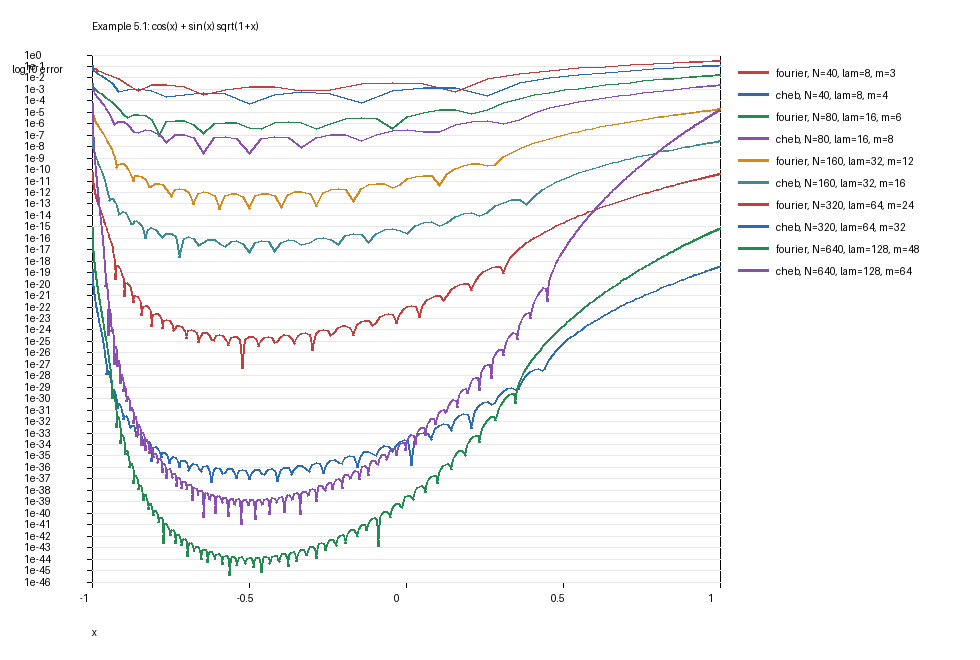

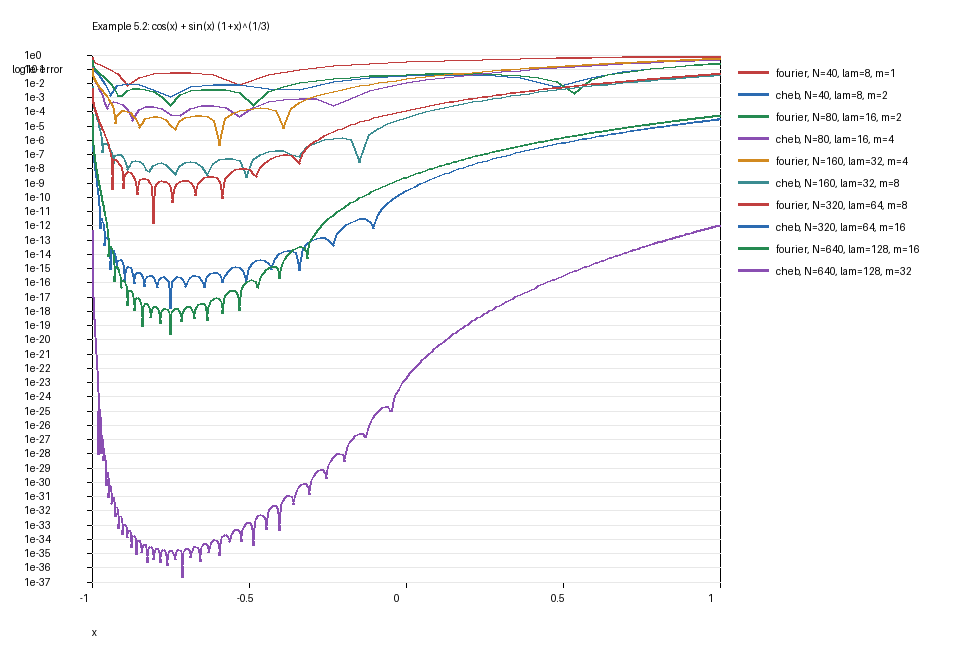

In [8]:

def draw_log_error_plot(results, title, width=980, height=660):
    image = Image.new('RGB', (width, height), 'white')
    draw = ImageDraw.Draw(image)
    font = ImageFont.load_default()
    left, right, top, bottom = 92, 260, 55, 78
    x0, x1 = left, width - right
    y0, y1 = top, height - bottom
    colors = ['#c13f3f', '#2c6bb1', '#258a51', '#8a4fb2', '#d28a20', '#3b8c91']
    positive = [err for result in results for err in result.errors if err > 0]
    log_min = int(mp.floor(min(mp.log10(err) for err in positive)))
    log_max = int(mp.ceil(max(mp.log10(err) for err in positive)))
    if log_min == log_max:
        log_min -= 1
        log_max += 1
    floor = mp.power(10, log_min)

    def px(x):
        return int(x0 + (x + 1) * (x1 - x0) / 2)

    def py(err):
        value = mp.log10(max(err, floor))
        return int(y1 - (value - log_min) * (y1 - y0) / (log_max - log_min))

    draw.rectangle([x0, y0, x1, y1], outline='black')
    draw.text((x0, 20), title, fill='black', font=font)
    draw.text((x0, height - 34), 'x', fill='black', font=font)
    draw.text((12, y0 + 8), 'log10 error', fill='black', font=font)

    for tick in [-1, -0.5, 0, 0.5, 1]:
        xp = px(mp.mpf(str(tick)))
        draw.line([xp, y1, xp, y1 + 5], fill='black')
        draw.text((xp - 12, y1 + 10), str(tick), fill='black', font=font)

    for exponent in range(log_min, log_max + 1):
        yp = py(mp.power(10, exponent))
        draw.line([x0 - 5, yp, x0, yp], fill='black')
        draw.line([x0, yp, x1, yp], fill='#e8e8e8')
        draw.text((x0 - 68, yp - 6), f'1e{exponent}', fill='black', font=font)

    for idx, result in enumerate(results):
        color = colors[idx % len(colors)]
        ordered = sorted(zip(result.x_values, result.errors), key=lambda item: item[0])
        points = [(px(x), py(error)) for x, error in ordered]
        draw.line(points, fill=color, width=2)
        lx, ly = x1 + 18, y0 + 12 + 22 * idx
        draw.line([lx, ly + 5, lx + 30, ly + 5], fill=color, width=3)
        label = f"{result.collocation}, N={result.N}, lam={result.lam}, m={result.m}"
        draw.text((lx + 38, ly), label, fill='black', font=font)
    return image

for example_key in ['5.1', '5.2']:
    subset = [result for result in all_results if result.example == example_key]
    display(draw_log_error_plot(subset, EXAMPLES[example_key]['title']))
